### 1. Check Custom Dataset and Model

In [1]:
import os
base_data_dir = 'Areal.v1i.yolov8'
base_model_dirs = ['models', 'cfg', 'data', 'utils']
print(os.path.exists(base_data_dir))
for dir in base_model_dirs:
    print(os.path.exists(dir))

True
True
True
True
True


### 2. Dataset Class, DataLoader Definition

In [2]:
from data_utils import T, YOLOv8Dataset, DataLoader, yolo_collate_fn, visualize_batch

train_img_dir = os.path.join(base_data_dir, "train", "images")
train_label_dir = os.path.join(base_data_dir, "train", "labels")
val_img_dir = os.path.join(base_data_dir, "valid", "images")
val_label_dir = os.path.join(base_data_dir, "valid", "labels")
# Add test paths similarly if needed
# test_img_dir = os.path.join(base_data_dir, "test", "images")
# test_label_dir = os.path.join(base_data_dir, "test", "labels")
# ---------------------
# Check if directories exist
if os.path.isdir(train_img_dir):
    print(f"Train image directory: {train_img_dir}")
else:
    print(f"Error: Train image directory not found: {train_img_dir}")
if os.path.isdir(train_label_dir):
    print(f"Train label directory: {train_label_dir}")
else:
    print(f"Error: Train label directory not found: {train_label_dir}")
if os.path.isdir(val_img_dir):
    print(f"Validation image directory: {val_img_dir}")
else:
    print(f"Warning: Validation image directory not found: {val_img_dir}")
if os.path.isdir(val_label_dir):
    print(f"Validation label directory: {val_label_dir}")
else:
    print(f"Warning: Validation label directory not found: {val_label_dir}")

Train image directory: Areal.v1i.yolov8\train\images
Train label directory: Areal.v1i.yolov8\train\labels
Validation image directory: Areal.v1i.yolov8\valid\images
Validation label directory: Areal.v1i.yolov8\valid\labels


In [3]:
# Define image transformations
transform = T.Compose([
    T.Resize((640, 640)), # Typical input size for YOLOv8
    T.ToTensor(),
])

# Create Train Dataset and DataLoader
train_dataset = YOLOv8Dataset(img_dir=train_img_dir,
                              label_dir=train_label_dir,
                              transform=transform)
print(len(train_dataset))

Debug: Found 93 potential image files in Areal.v1i.yolov8\train\images
Debug: Found 93 potential label files in Areal.v1i.yolov8\train\labels
Debug: Matched 93 image-label pairs.
93


Train dataset loaded successfully. Total samples: 93

--- Batch 1 ---
Images batch shape: torch.Size([4, 3, 640, 640])
Labels batch length: 4
  Label tensor 0 shape: torch.Size([1, 5])
    Box 0: class=0, x=0.4820, y=0.5805, w=0.4880, h=0.3377
  Label tensor 1 shape: torch.Size([1, 5])
    Box 0: class=1, x=0.4964, y=0.4904, w=0.9543, h=0.7296
  Label tensor 2 shape: torch.Size([1, 5])
    Box 0: class=0, x=0.5072, y=0.5889, w=0.4928, h=0.3462
  Label tensor 3 shape: torch.Size([1, 5])
    Box 0: class=0, x=0.4940, y=0.5084, w=0.3654, h=0.5252


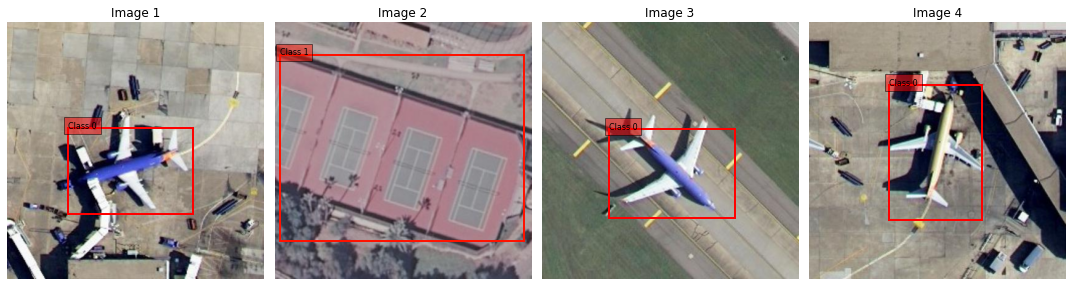

In [4]:
train_loader = DataLoader(train_dataset,
                          batch_size=4,      # Reduced batch size for testing
                          shuffle=True,      # Shuffle training data
                          num_workers=0,     # Set to 0 for debugging, especially on Windows
                          collate_fn=yolo_collate_fn, # Use custom collate function
                          pin_memory=True)   # Optimize data transfer to GPU if available

print(f"Train dataset loaded successfully. Total samples: {len(train_dataset)}")

# Test loading a batch from the DataLoader
for i, batch_data in enumerate(train_loader):
     if batch_data is None or batch_data[0] is None:
         print(f"--- Failed to load Batch {i+1} (collate_fn returned None) ---")
         continue # Try next batch

     images, labels = batch_data
     print(f"\n--- Batch {i+1} ---")
     print(f"Images batch shape: {images.shape}") # Expected: [batch_size, C, H, W]
     print(f"Labels batch length: {len(labels)}") # Expected: batch_size (list of tensors)
     for j, label_tensor in enumerate(labels):
        print(f"  Label tensor {j} shape: {label_tensor.shape}")  # Expected: [Num_objects_in_img_j, 5]
        
        # Print the actual labels (up to 5 for readability)
        max_labels_to_show = min(5, label_tensor.shape[0])
        for k in range(max_labels_to_show):
            cls_id, x, y, w, h = label_tensor[k].tolist()
            print(f"    Box {k}: class={int(cls_id)}, x={x:.4f}, y={y:.4f}, w={w:.4f}, h={h:.4f}")
        
        # If there are more labels than shown, indicate this
        if label_tensor.shape[0] > max_labels_to_show:
            print(f"    ... and {label_tensor.shape[0] - max_labels_to_show} more boxes")
     visualize_batch(images, labels)
     if i == 0:
         break # Only check the first batch

In [5]:
# Create Validation Dataset and DataLoader
# Only create validation loader if directories exist
if os.path.isdir(val_img_dir) and os.path.isdir(val_label_dir):
    val_dataset = YOLOv8Dataset(img_dir=val_img_dir,
                                label_dir=val_label_dir,
                                transform=transform)

    if len(val_dataset) > 0:
        val_loader = DataLoader(val_dataset,
                                batch_size=4,
                                shuffle=False, # No need to shuffle validation data
                                num_workers=0,
                                collate_fn=yolo_collate_fn,
                                pin_memory=True)
        print(f"\nValidation dataset loaded successfully. Total samples: {len(val_dataset)}")
    else:
         print("Warning: No valid samples found after creating Validation dataset.")
else:
    print("Warning: Validation directories not valid. Skipping Validation DataLoader creation.")

Debug: Found 25 potential image files in Areal.v1i.yolov8\valid\images
Debug: Found 25 potential label files in Areal.v1i.yolov8\valid\labels
Debug: Matched 25 image-label pairs.

Validation dataset loaded successfully. Total samples: 25


### 3. Load Model & Forward pass

In [6]:
import torch
import yaml

# --- 1. Manually Set Command-line Arguments ---
class DummyOpt:
    pass

opt = DummyOpt()
opt.workers = 8
opt.device = "cpu"  # Set to "cpu" if GPU is not available
opt.batch_size = 4
opt.data = "data/coco.yaml"         # Data configuration file (includes number of classes, names, etc.)
opt.img_size = [640, 640]              # Image sizes for [train, test]
opt.cfg = "cfg/training/yoloOW.yaml" # Model configuration file
opt.weights = ""                     # If empty, create model from scratch (no pretrained weights)
opt.name = "rcs-yolo"
opt.hyp = "data/hyp.scratch.p5.yaml"   # Hyperparameter file
opt.single_cls = False               # Whether to treat data as a single class

# --- 2. Load Device, Hyperparameters, and Dataset Information ---
device = torch.device("cpu")
print("Device:", device)

with open(opt.hyp, 'r') as f:
    hyp = yaml.safe_load(f)
print("Hyperparameters loaded from", opt.hyp)

with open(opt.data, 'r') as f:
    data_dict = yaml.safe_load(f)
nc = 1 if opt.single_cls else int(data_dict['nc'])
names = data_dict['names']
print(f"Number of classes: {nc}, names: {names}")

Device: cpu
Hyperparameters loaded from data/hyp.scratch.p5.yaml
Number of classes: 2, names: ['airplane', 'tenniscourt']


C:\Users\LSH\Anaconda3\envs\Torch_1.10\lib\site-packages\torch\nn\functional.py:3680: UserWarning: The default behavior for interpolate/upsample with float scale_factor changed in 1.6.0 to align with other frameworks/libraries, and now uses scale_factor directly, instead of relying on the computed output size. If you wish to restore the old behavior, please set recompute_scale_factor=True. See the documentation of nn.Upsample for details. 
  "The default behavior for interpolate/upsample with float scale_factor changed "


Model loaded from cfg/training/yoloOW.yaml

Using batch from train_loader:
Images batch shape: torch.Size([4, 3, 640, 640])
Number of label tensors: 4
  Label tensor 0 shape: torch.Size([2, 5])
tensor([[0.00000, 0.31370, 0.69952, 0.39663, 0.34615],
        [0.00000, 0.71034, 0.37861, 0.41346, 0.41587]])
  Label tensor 1 shape: torch.Size([4, 5])
tensor([[0.00000, 0.53365, 0.45433, 0.36779, 0.37380],
        [0.00000, 0.32692, 0.71394, 0.24399, 0.30168],
        [0.00000, 0.09375, 0.76082, 0.18750, 0.24760],
        [0.00000, 0.74279, 0.24760, 0.26562, 0.20913]])
  Label tensor 2 shape: torch.Size([1, 5])
tensor([[0.00000, 0.52764, 0.50601, 0.77404, 0.47716]])
  Label tensor 3 shape: torch.Size([1, 5])
tensor([[1.00000, 0.49159, 0.60577, 0.92308, 0.43029]])


C:\Jupyter_Home\CAU_25_Spring_ComputerVision-main (1)\CAU_25_Spring_ComputerVision-main\Week05\data_utils.py:236: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


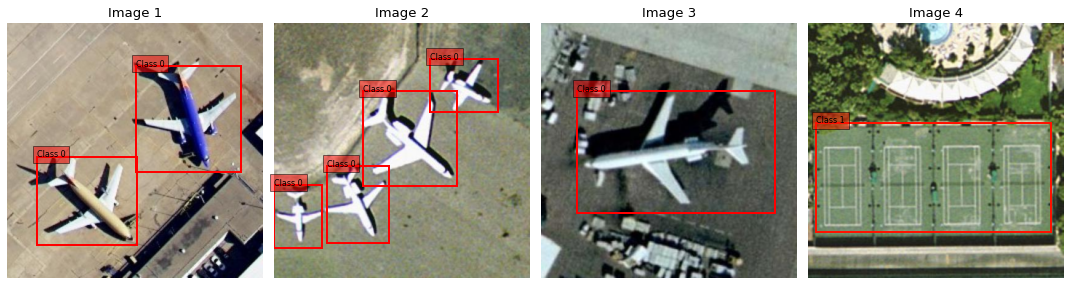

In [7]:
# --- 3. Load Model (Using Model class from models/yolo.py) ---
from models.yolo import Model
model = Model(opt.cfg, ch=3, nc=nc).to(device)
model.train()  # Set model to training mode
print("Model loaded from", opt.cfg)

# Assign additional attributes required by ComputeLoss (e.g., hyp and gr)
model.hyp = hyp
model.gr = 1.0   

# --- 4. Get a Batch from the DataLoader ---
# Assume that a custom DataLoader (train_loader) has already been created.
batch = next(iter(train_loader))
images, labels = batch
print("\nUsing batch from train_loader:")
print(f"Images batch shape: {images.shape}")
print(f"Number of label tensors: {len(labels)}")
for j, label_tensor in enumerate(labels):
    print(f"  Label tensor {j} shape: {label_tensor.shape}")
    print(label_tensor)
visualize_batch(images, labels)

In [8]:
# --- 5. Construct Targets Tensor ---
# For YOLO loss, each label needs to include the image index.
all_targets = []
for i, lab in enumerate(labels):
    if lab.shape[0] > 0:
        image_idx = torch.full((lab.shape[0], 1), i, dtype=lab.dtype, device=lab.device)
        all_targets.append(torch.cat((image_idx, lab), dim=1))
if all_targets:
    targets_tensor = torch.cat(all_targets, dim=0)  # Shape: [total_objects, 6]
else:
    targets_tensor = torch.empty((0, 6), device=device)
print(f"Constructed targets tensor of shape: {targets_tensor.shape}")
print(targets_tensor)

Constructed targets tensor of shape: torch.Size([8, 6])
tensor([[0.00000, 0.00000, 0.31370, 0.69952, 0.39663, 0.34615],
        [0.00000, 0.00000, 0.71034, 0.37861, 0.41346, 0.41587],
        [1.00000, 0.00000, 0.53365, 0.45433, 0.36779, 0.37380],
        [1.00000, 0.00000, 0.32692, 0.71394, 0.24399, 0.30168],
        [1.00000, 0.00000, 0.09375, 0.76082, 0.18750, 0.24760],
        [1.00000, 0.00000, 0.74279, 0.24760, 0.26562, 0.20913],
        [2.00000, 0.00000, 0.52764, 0.50601, 0.77404, 0.47716],
        [3.00000, 1.00000, 0.49159, 0.60577, 0.92308, 0.43029]])


In [9]:
# --- 6. Run Model Forward Pass ---
outputs = model(images)
print("--- Forward Pass ---")

# --- 7. Compute Loss (Using ComputeLoss) ---
from utils.loss import ComputeLoss
compute_loss = ComputeLoss(model)  # ComputeLoss is defined in utils/loss.py
loss, loss_items = compute_loss(outputs, targets_tensor)
# loss_items: [box_loss, obj_loss, cls_loss, total_loss]
print("\nLoss components:")
print(f"  Box Loss: {loss_items[0].item()}")
print(f"  Obj Loss: {loss_items[1].item()}")
print(f"  Cls Loss: {loss_items[2].item()}")
print(f"  Total Loss: {loss_items[3].item()}")

print("Before backward() call. Gradient values:")
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        print(f"  {name} gradient norm: {grad_norm}")
        break
loss.backward()
print("\nAfter backward() call. Gradient values:")
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        print(f"  {name} gradient norm: {grad_norm}")
        break

print("\nForward and backward pass with ComputeLoss completed successfully.")

--- Forward Pass ---

Loss components:
  Box Loss: 0.04549568146467209
  Obj Loss: 0.01689322479069233
  Cls Loss: 0.3636641800403595
  Total Loss: 0.42605307698249817
Before backward() call. Gradient values:

After backward() call. Gradient values:
  model.0.conv1.rbr_dense.0.weight gradient norm: 56.48033142089844

Forward and backward pass with ComputeLoss completed successfully.
